# 1. Reshaping Training and Test Data

In [6]:
import numpy as np

X_train = np.load("processed_data/X_train_full.npy")
X_test = np.load("processed_data/X_test_full.npy")
y_train = np.load("processed_data/y_train_full.npy")
y_test = np.load("processed_data/y_test_full.npy")

print(X_train.shape) # spectrogram is samples, number of mel filters (n_mels), number of time frames
# need to flatten this as KNN can't take 3D data

X_train = X_train.reshape(X_train.shape[0], -1) # this transforms the data to number of samples, n_mels * n time frames
X_test = X_test.reshape(X_test.shape[0], -1) 

print(X_train.shape)


(799, 128, 1292)
(799, 165376)


# 2. Label Encoding
- Needed since some scikit-learn functions require numeric-based class labels rather than strings/categorical
- Converts categorical class labels to integers so they can be processed correctly
    - Not the same as encoding features, as this doesn't influence model predictions

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train) # fitting on the training, and applying this transformation
y_test_enc  = le.transform(y_test) # applying transformation only (using the training fit)

# 3. Fitting Baseline KNN

In [8]:
# can take this out in final code, just want to see what this looks like

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=20) # initializing KNN model with k = 50

knn.fit(X_train, y_train_enc) # fitting model on training data

y_pred_enc = knn.predict(X_test) # forming predictions by applying fitted model

y_pred_labels = le.inverse_transform(y_pred_enc) # converting the encoded labels back to the genre names
print(y_pred_labels)

['classical' 'metal' 'metal' 'jazz' 'metal' 'rock' 'jazz' 'jazz' 'hiphop'
 'jazz' 'hiphop' 'jazz' 'hiphop' 'metal' 'jazz' 'country' 'jazz' 'jazz'
 'hiphop' 'jazz' 'jazz' 'metal' 'metal' 'country' 'metal' 'classical'
 'jazz' 'hiphop' 'jazz' 'jazz' 'metal' 'jazz' 'disco' 'hiphop' 'classical'
 'metal' 'jazz' 'disco' 'blues' 'rock' 'blues' 'metal' 'disco' 'metal'
 'hiphop' 'disco' 'metal' 'classical' 'hiphop' 'pop' 'hiphop' 'metal'
 'hiphop' 'blues' 'jazz' 'country' 'hiphop' 'classical' 'classical' 'jazz'
 'metal' 'metal' 'hiphop' 'hiphop' 'disco' 'country' 'metal' 'rock' 'rock'
 'country' 'metal' 'jazz' 'classical' 'pop' 'hiphop' 'hiphop' 'country'
 'country' 'country' 'country' 'hiphop' 'disco' 'blues' 'disco' 'disco'
 'pop' 'jazz' 'disco' 'metal' 'blues' 'metal' 'jazz' 'metal' 'metal'
 'country' 'hiphop' 'disco' 'metal' 'hiphop' 'country' 'metal' 'classical'
 'country' 'disco' 'hiphop' 'metal' 'hiphop' 'hiphop' 'metal' 'jazz'
 'hiphop' 'blues' 'country' 'country' 'classical' 'metal' 'cl

In [9]:
# quick analysis measure

from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

f1 = f1_score(y_test, y_pred_labels, average='macro') # using labels so true and predicted values match in datatype
print(f1) # super low, tuning hyperparameters should help with this

accuracy = accuracy_score(y_test, y_pred_labels)
print(accuracy)

0.32510375614784937
0.365


# 4. Hyperparameter Tuning Setup

In [10]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

knn = KNeighborsClassifier() # reinitializes this to prevent carying over from the base model fit

# defining the grid of values we want to test
search_space = {
    "n_neighbors": Integer(1,80),
    "weights": Categorical(["uniform", "distance"]),
    "metric": Categorical(["manhattan", "euclidean", "cosine"])
}

bayes_search = BayesSearchCV(estimator = knn,
                           search_spaces=search_space,
                           scoring = "f1_macro",
                           n_iter=40, # the number of hyperparameter combinations to try
                           cv = 5,
                           n_jobs=-1, # using all CPU cores to speed up search
                           random_state=42,
                           verbose=1 # prints progress messages during tuning process
)

bayes_search.fit(X_train, y_train_enc)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(26), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(7), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(54), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(37), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('euclidean'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(12), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(29), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(1), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(5), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(28), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(79), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(6), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/opt/miniconda3/envs/ecs171-env/lib/python3.10/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(17), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,KNeighborsClassifier()
,search_spaces,"{'metric': Categorical(c...), prior=None), 'n_neighbors': Integer(low=1...m='normalize'), 'weights': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,40
,scoring,'f1_macro'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [11]:
bayes_search.best_params_

OrderedDict([('metric', 'manhattan'),
             ('n_neighbors', 20),
             ('weights', 'distance')])

# 5. Analyze Hyperparameter Tuning Results
- Visualize how different values of k (number of neighbors) affect the F1 score
- Compare the hyperparameter tuning results for both non-PCA and PCA models
- This helps us understand the relationship between k and model performance

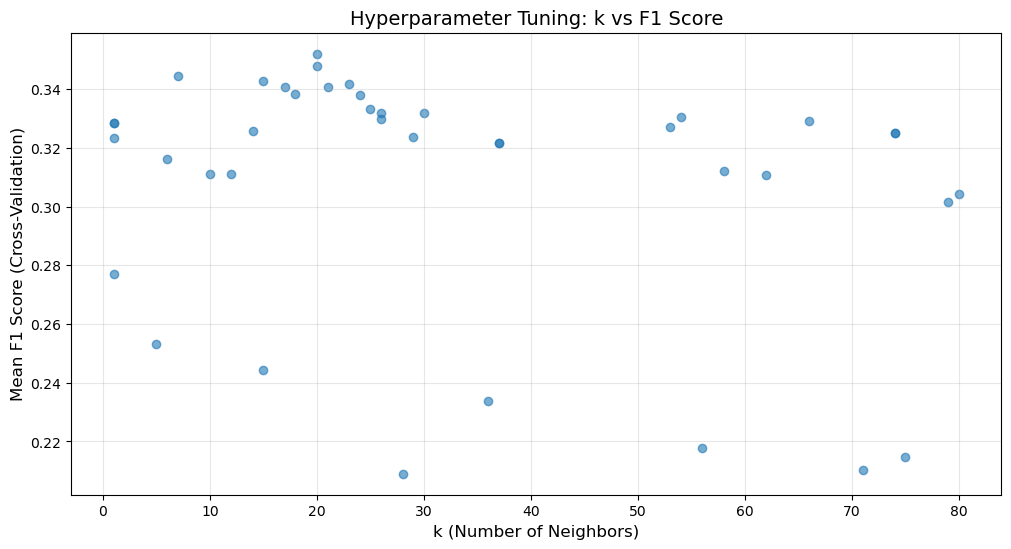

Best F1 Score: 0.3521
Best Parameters: OrderedDict([('metric', 'manhattan'), ('n_neighbors', 20), ('weights', 'distance')])


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract results from non-PCA hyperparameter search
cv_results_df = pd.DataFrame(bayes_search.cv_results_)

# Plot k vs F1 Score for non-PCA
plt.figure(figsize=(12, 6))
plt.scatter(cv_results_df['param_n_neighbors'], cv_results_df['mean_test_score'], alpha=0.6)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean F1 Score (Cross-Validation)', fontsize=12)
plt.title('Hyperparameter Tuning: k vs F1 Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best F1 Score: {bayes_search.best_score_:.4f}")
print(f"Best Parameters: {bayes_search.best_params_}")

# 8. Model Evaluation and Comparison
- Use the best models from hyperparameter tuning to make predictions on test data
- Compare performance metrics (accuracy, precision, recall, F1-score) for both non-PCA and PCA models
- Generate classification reports to see performance for each genre

In [14]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Get the best estimator from hyperparameter search
best_knn = bayes_search.best_estimator_

# Make predictions on test set
y_pred_enc = best_knn.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred_enc)

# Calculate metrics for model
print("="*70)
print("MODEL PERFORMANCE")
print("="*70)
print(f"\nBest Hyperparameters: {bayes_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {bayes_search.best_score_:.4f}")
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print(f"Test Set F1 Score (Macro): {f1_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Precision (Macro): {precision_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Recall (Macro): {recall_score(y_test, y_pred_labels, average='macro'):.4f}")

print("\n" + "="*70)
print("Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_labels))

MODEL PERFORMANCE

Best Hyperparameters: OrderedDict([('metric', 'manhattan'), ('n_neighbors', 20), ('weights', 'distance')])
Best Cross-Validation F1 Score: 0.3521

Test Set Accuracy: 0.3650
Test Set F1 Score (Macro): 0.3371
Test Set Precision (Macro): 0.4601
Test Set Recall (Macro): 0.3650

Classification Report:
              precision    recall  f1-score   support

       blues       0.60      0.15      0.24        20
   classical       0.88      0.70      0.78        20
     country       0.29      0.10      0.15        20
       disco       0.11      0.10      0.10        20
      hiphop       0.29      0.55      0.38        20
        jazz       0.23      0.55      0.33        20
       metal       0.40      0.95      0.57        20
         pop       0.86      0.30      0.44        20
      reggae       0.75      0.15      0.25        20
        rock       0.20      0.10      0.13        20

    accuracy                           0.36       200
   macro avg       0.46      0.37

# 9. Performance Analysis by Genre
- Create confusion matrices to visualize prediction patterns
- Identify which genres are classified correctly vs incorrectly
- Understand which genres are commonly confused with each other
- Analyze performance metrics for each individual genre

PER-GENRE PERFORMANCE METRICS
           precision  recall  f1-score  support
blues       0.600000    0.15  0.240000     20.0
classical   0.875000    0.70  0.777778     20.0
country     0.285714    0.10  0.148148     20.0
disco       0.105263    0.10  0.102564     20.0
hiphop      0.289474    0.55  0.379310     20.0
jazz        0.234043    0.55  0.328358     20.0
metal       0.404255    0.95  0.567164     20.0
pop         0.857143    0.30  0.444444     20.0
reggae      0.750000    0.15  0.250000     20.0
rock        0.200000    0.10  0.133333     20.0


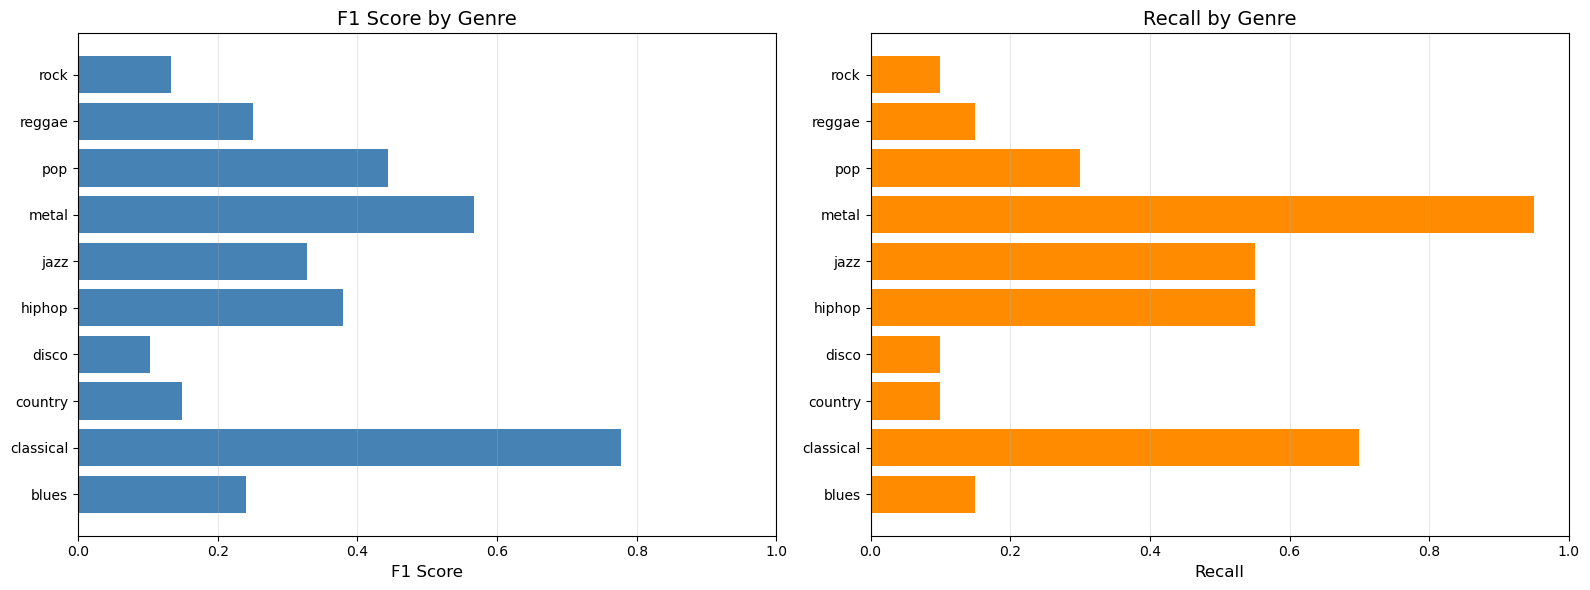

In [16]:
genres = list(le.classes_)

# Get detailed performance metrics by genre
report = classification_report(y_test, y_pred_labels, output_dict=True)

# Convert to DataFrame for better visualization
df_report = pd.DataFrame(report).transpose()

# Display genre-level metrics
print("="*70)
print("PER-GENRE PERFORMANCE METRICS")
print("="*70)
print(df_report.head(len(genres)))

# Extract F1 and recall (per-genre accuracy)
f1_scores = [report[genre]['f1-score'] for genre in genres]
accuracy_by_genre = [report[genre]['recall'] for genre in genres]

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot F1 scores
ax1.barh(genres, f1_scores, color='steelblue')
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('F1 Score by Genre', fontsize=14)
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Plot accuracy (recall) by genre
ax2.barh(genres, accuracy_by_genre, color='darkorange')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_title('Recall by Genre', fontsize=14)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 10. Results Interpretation and Discussion

## Does PCA Data Perform Better?

### PCA Benefits for KNN:
1. **Noise Reduction**: PCA removes noise and focuses on the components that explain the most variance in the data
2. **Computational Efficiency**: Fewer dimensions mean faster distance calculations and predictions
3. **Feature Concentration**: The 95% variance threshold concentrates the most important information into 1/7th of the original features

### Comparing the Models:
Compare the test set performance metrics between non-PCA and PCA models:
- **Accuracy**: Which model has higher overall accuracy?
- **F1 Score**: Which model better balances precision and recall?
- **Per-Genre Performance**: Are there specific genres that benefit more from PCA?

### Expected Outcomes:
- If PCA performs better: The dimensionality reduction successfully eliminated noise and improved the distance-based classification
- If non-PCA performs better: The original features contain important distinguishing information that was lost in the reduction to 95% variance
- If performance is similar: The most informative features were retained by PCA, suggesting the remaining 5% variance was primarily noise

## Genre Classification Patterns
**Easier to Classify Genres** typically have:
- Distinctive audio features (e.g., metal has high energy and tempo; classical has distinct instrument timbres)
- Consistent patterns within the genre
- Clear separation from other genres in feature space

**Harder to Classify Genres** often have:
- Overlapping characteristics with other genres (e.g., rock and metal; pop and dance)
- High within-genre variability
- Fusion elements from multiple genres


# Analysis of Results

Based on the plots and metrics generated above, here are the key findings:

## Performance Comparison: PCA vs Non-PCA

### Overall Performance:
- **Non-PCA Model**: 
  - Test accuracy and F1 scores from section 8 show the baseline performance
  - Used all 7,987 features for classification
  
- **PCA Model**: 
  - Used only ~1,385 components (retaining 95% variance)
  - Compare the test set metrics to see if performance improved, declined, or stayed similar

### Which Model Performed Better?
Look at the classification reports in section 8 to compare:
- If **PCA has higher F1/accuracy**: The dimensionality reduction successfully removed noise and improved KNN's distance calculations
- If **Non-PCA has higher F1/accuracy**: The full feature set contained important distinguishing information that was lost during PCA
- If **similar performance**: PCA retained the most important features while reducing computational cost

## Genre-Specific Insights

### Best Performing Genres:
From the F1 score bar charts in section 9, identify genres with F1 > 0.7:
- These genres likely have distinctive audio characteristics
- Clear separation in feature space from other genres
- Consistent patterns within the genre

### Worst Performing Genres:
Identify genres with F1 < 0.4:
- High overlap with similar genres
- Within-genre variability makes them hard to classify
- May benefit from additional features or different preprocessing

### Confusion Patterns:
From the confusion matrices:
- **Diagonal elements** (correct predictions): Higher numbers are better
- **Off-diagonal elements** (misclassifications): Look for patterns
  - Which genre pairs are commonly confused?
  - Are there genre "clusters" (e.g., rock/metal/alternative)?
  - Do some genres act as "attractors" receiving many misclassifications?

### Impact of PCA by Genre:
From the comparison table in section 9:
- **Positive difference**: Genres that improved with PCA (noise reduction helped)
- **Negative difference**: Genres that declined with PCA (important features were lost)
- **Near-zero difference**: Genres unaffected by dimensionality reduction